# 1.ValueError                                

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform("Just one sentence.")


ValueError: Iterable over raw text documents expected, string object received.

## Solution 1

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
doc = ["Just one sentence."] # Pass as array instead fo string
X = vectorizer.fit_transform(doc) 
print(X.toarray)
print(vectorizer.get_feature_names_out())

<bound method _cs_matrix.toarray of <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3 stored elements and shape (1, 3)>>
['just' 'one' 'sentence']


# 2.ImportError                               

In [4]:
from textblob import textBlob
TextBlob("Great work!").sentiment

ImportError: cannot import name 'textBlob' from 'textblob' (C:\Users\kgopi\anaconda3\envs\GENAI\Lib\site-packages\textblob\__init__.py)

## Solution 2

In [8]:
from textblob import TextBlob # Typo Error textBlob
TextBlob("Great work!").sentiment

Sentiment(polarity=1.0, subjectivity=0.75)

# 3.ValueError                                

In [9]:
from gensim import corpora, models
corpus = []
lda = models.LdaModel(corpus=corpus, num_topics=2, id2word=None)

ModuleNotFoundError: No module named 'gensim'

## Solution 3

In [13]:
# !pip install gensim
# corpus was empty
# LDA needs dictionary and a corpus

from gensim import corpora, models

docs = [
    ["machine", "learning", "ai"],
    ["nlp", "language", "text"],
    ["machine", "deep", "learning"]
]

dictionary = corpora.Dictionary(docs)
corpus = [dictionary.doc2bow(doc) for doc in docs]

lda = models.LdaModel(
    corpus=corpus,
    num_topics=2,
    id2word=dictionary,
    passes=10
)

for topic in lda.print_topics():
    print(topic)                      


(0, '0.201*"learning" + 0.200*"machine" + 0.120*"deep" + 0.120*"language" + 0.120*"text" + 0.120*"nlp" + 0.118*"ai"')
(1, '0.148*"machine" + 0.146*"learning" + 0.145*"ai" + 0.141*"nlp" + 0.140*"text" + 0.140*"language" + 0.139*"deep"')


# 4.AttributeError                            

In [14]:
from sklearn.feature_extraction.text import CountVectorizer
docs = [1234, 5678]
cv = CountVectorizer()
cv.fit_transform(docs)


AttributeError: 'int' object has no attribute 'lower'

## Solution 4


In [17]:
from sklearn.feature_extraction.text import CountVectorizer
docs = ["1234", "5678"] #Pass as string instead of integer
cv = CountVectorizer()
cv.fit_transform(docs)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2 stored elements and shape (2, 2)>

# 5.TypeError                                 

In [18]:
from wordcloud import WordCloud
import pandas as pd

df = pd.DataFrame({'text': ['This is great', None]})
text = " ".join(df['text'])
wc = WordCloud().generate(text)


TypeError: sequence item 1: expected str instance, float found

## Solution 5

In [23]:
# DataFrame contains a None value
# Pandas converts None to NaN (a float)
# Replace missing values with empty strings

from wordcloud import WordCloud
import pandas as pd

df = pd.DataFrame({'text': ['This is great', None]})
text = " ".join(df['text'].fillna(''))
wc = WordCloud().generate(text)
print(text)

This is great 


# 6.TypeError                                 

TypeError: Image data of dtype <U13 cannot be converted to float

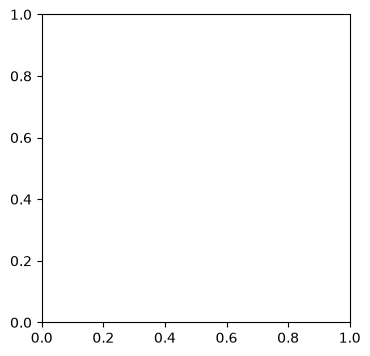

In [24]:
from wordcloud import WordCloud
import pandas as pd
import matplotlib.pyplot as plt

# Create the DataFrame
df = pd.DataFrame({'text': ['This is great', None]})

# Combine non-null text
text = " ".join(df['text'].dropna())

# Generate word cloud
wc = WordCloud(background_color='white').generate(text)

# Display the word cloud
plt.figure(figsize=(8, 4))
plt.imshow(text, interpolation='bilinear')
plt.axis('off')  # Hide axis
plt.title("Word Cloud Output", fontsize=16)
plt.show()





## Solution 6

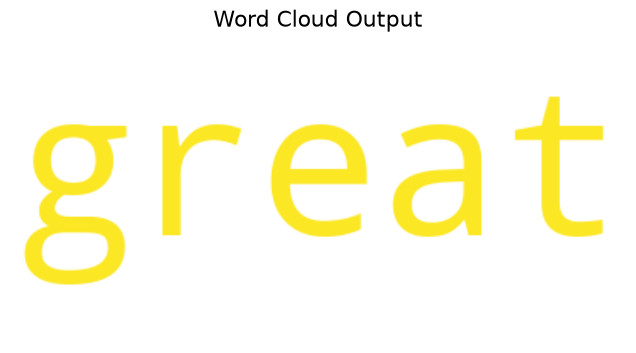

In [25]:
from wordcloud import WordCloud
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame
df = pd.DataFrame({'text': ['This is great', None]})

# Combine non-null text
text = " ".join(df['text'].dropna())

# Generate word cloud
wc = WordCloud(background_color='white').generate(text)

# Display word cloud
plt.figure(figsize=(8, 4))
plt.imshow(wc, interpolation='bilinear')   # imshow expects image array, use wc instead of text
plt.axis('off')
plt.title("Word Cloud Output", fontsize=16)
plt.show()